<a href="https://colab.research.google.com/github/Muqtarali/Deep-Learning/blob/main/Functional_api/age_gender_revised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!pip install opendatasets
!pip install pandas

In [14]:
import opendatasets as od
import pandas

od.download(
    "https://www.kaggle.com/datasets/jangedoo/utkface-new")


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: af
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new


100%|██████████| 331M/331M [00:09<00:00, 37.0MB/s]


In [18]:

import os

# Sub-folder path jahan images hain
data_dir = '/content/utkface-new/UTKFace'

# Kitni images hain check karne ke liye:
print("Total images:", len(os.listdir(data_dir)))

Total images: 23708


In [22]:
import os
import pandas as pd
import tensorflow as tf

# Data directory path
data_dir = '/content/utkface-new/UTKFace'

# 1. Filenames se Labels parse karke DataFrame banayein
file_paths = []
ages = []
genders = []

for fname in os.listdir(data_dir):
    if fname.endswith('.jpg'):
        parts = fname.split('_')
        if len(parts) >= 3:
            try:
                ages.append(int(parts[0]))
                genders.append(int(parts[1]))
                file_paths.append(os.path.join(data_dir, fname))
            except ValueError:
                continue

df = pd.DataFrame({
    'age': ages,
    'gender': genders,
    'file_path': file_paths,
})

print(f"Total Images Loaded: {len(df)}")
df.head()

Total Images Loaded: 23708


,age,gender,file_path
0,33,1,/content/utkface-new/UTKFace/33_1_1_2017011621...
1,29,0,/content/utkface-new/UTKFace/29_0_0_2017010420...
2,2,0,/content/utkface-new/UTKFace/2_0_2_20161219162...
3,67,0,/content/utkface-new/UTKFace/67_0_0_2017010421...
4,26,1,/content/utkface-new/UTKFace/26_1_0_2017011616...


In [26]:
from sklearn.model_selection import train_test_split

# Automatically exact percentage split kar deta hai (e.g., 80% train, 20% test)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [27]:
train_df.shape

(18966, 3)

In [28]:
test_df.shape

(4742, 3)

In [31]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [36]:
train_dataget=ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2
)

test_datagen=ImageDataGenerator(
    rescale=1./255
)

In [38]:
from IPython.testing import test
train_generator = train_dataget.flow_from_dataframe(
    dataframe=train_df,
    x_col='file_path',
    y_col=['age', 'gender'],     # <-- Comma (,) yahan missing tha
    target_size=(224, 224),
    batch_size=32,
    class_mode='multi_output'    # <-- Multiple targets (Age + Gender) ke liye 'multi_output' use hota hai
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='file_path',
    y_col=['age', 'gender'],
    target_size=(224, 224),
    batch_size=32,
    class_mode='multi_output'
)


Found 18966 validated image filenames.
Found 4742 validated image filenames.


In [41]:
import keras
from keras.applications.vgg16 import VGG16
from keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

In [42]:
cov_model=VGG16(include_top=False,input_shape=(224,224,3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [43]:
cov_model.trainable=False


In [47]:
from keras.applications.resnet50 import ResNet50
from keras.layers import *
from keras.models import Model

In [58]:

output = cov_model.output

flatten = Flatten()(output)

dense1=Dense(512,activation='relu')(flatten)
dense2=Dense(521,activation='relu')(flatten)

dense3=Dense(512,activation='relu')(dense1)
dense4=Dense(512,activation='relu')(dense2)

output1=Dense(1,activation='linear',name='age')(dense3)
output2=Dense(1,activation='sigmoid',name='gender')(dense4)

model=Model(inputs=cov_model.input,outputs=[output1,output2])


In [59]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 41,162,571 (157.02 MB)

 Trainable params: 26,447,883 (100.89 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

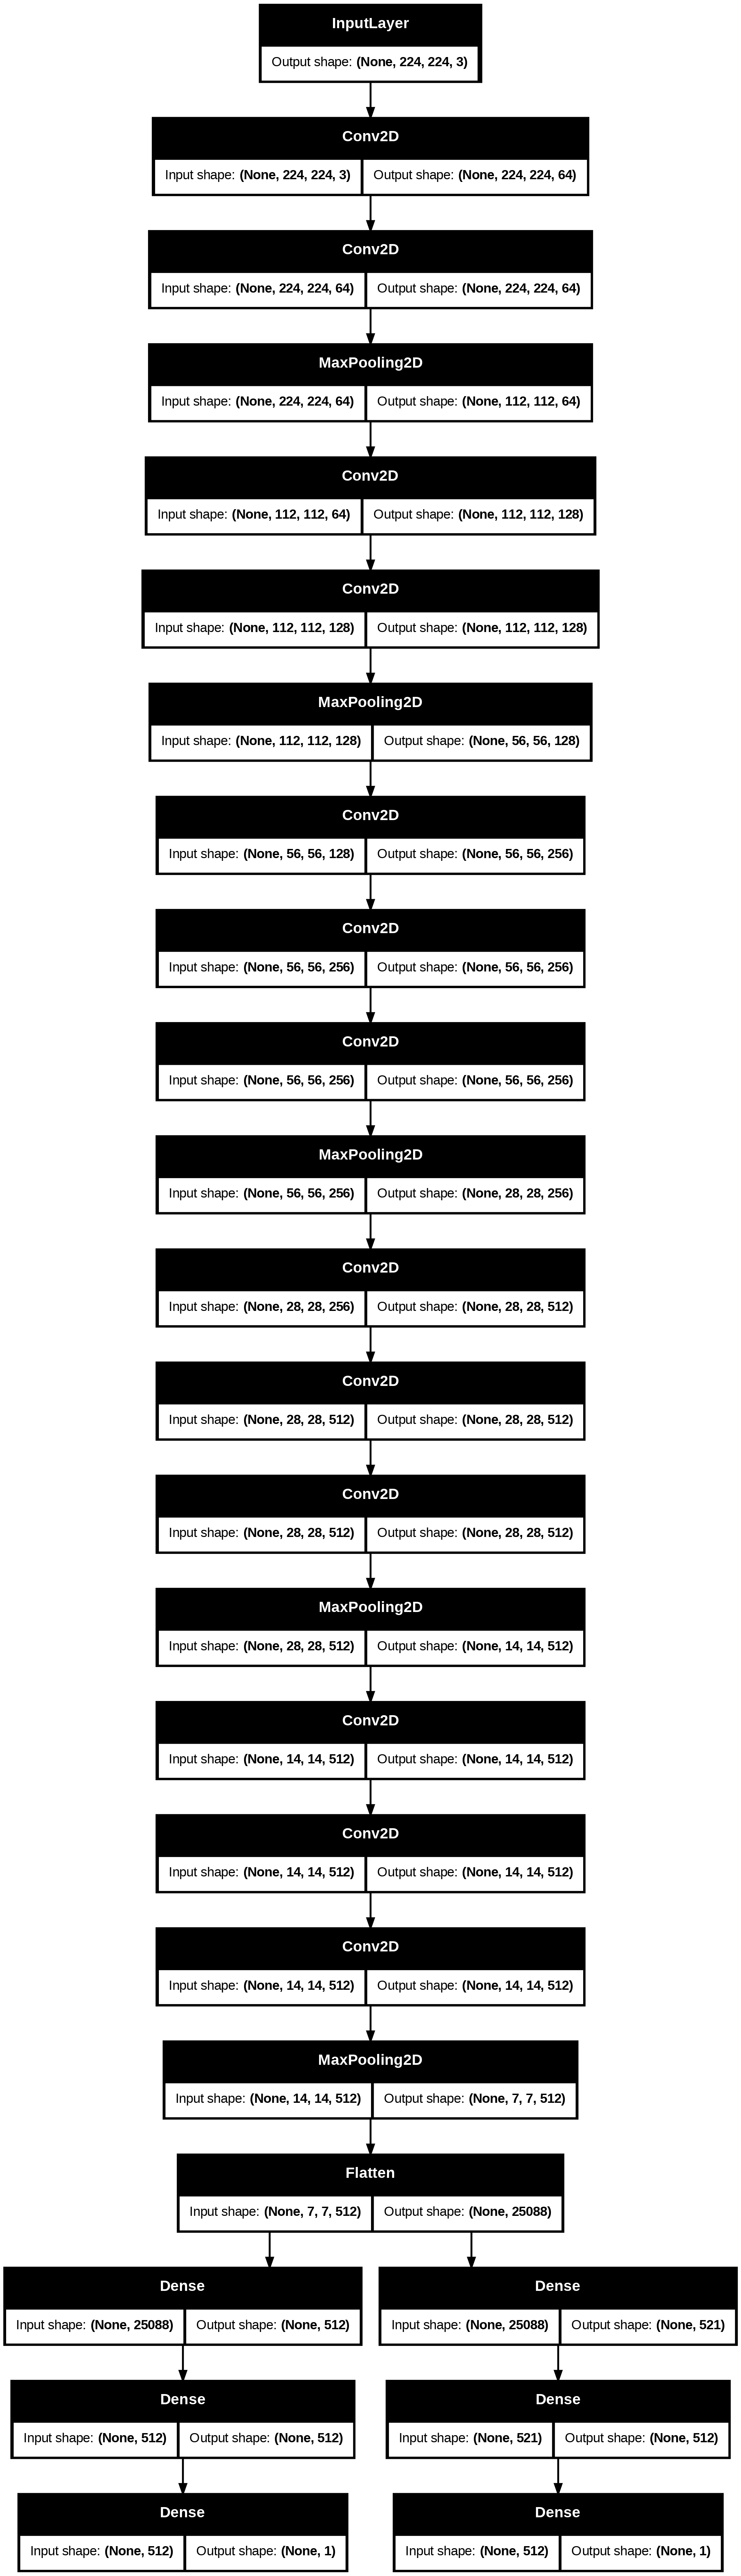

In [60]:
from keras.utils import plot_model
plot_model(model,show_shapes=True)

In [62]:
model.compile(
    optimizer='adam',
    loss={'age': 'mse', 'gender': 'binary_crossentropy'},
    metrics={'age': 'mae', 'gender': 'accuracy'}
)

In [63]:
model.fit(train_generator,batch_size=32,epochs=10,validation_data=test_generator)

TypeError: `output_signature` must contain objects that are subclass of `tf.TypeSpec` but found <class 'list'> which is not.